# 006 Fault Tolerance

这是 LangGraph 学习线的第六份 Notebook。

官方参考：

- https://docs.langchain.com/oss/python/langgraph/fault-tolerance

学习目标：

1. 理解 fault tolerance 为什么是长运行 agent 的核心能力
2. 学会用 `RetryPolicy` 处理临时错误
3. 学会用 checkpoint 在节点失败后查看状态
4. 学会从失败节点继续执行 graph
5. 理解重试和外部副作用之间的幂等性风险

这一讲使用当前环境可用的 `langgraph==1.1.9` 能力。官方文档中的 per-node timeout 和 error handler 属于较新能力，本课先不实操。

## 1. Fault tolerance 解决什么问题

长运行 agent 不可能假设每一步都成功。

真实系统里经常会遇到：

- 网络请求短暂失败
- 模型服务超时
- 工具执行抛异常
- 人工审批中断
- 进程重启

Fault tolerance 的核心不是“永远不失败”。

而是：

```text
失败后能知道失败在哪里，
能保留已完成状态，
能安全地重试或恢复。
```

In [82]:
import importlib.metadata

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import RetryPolicy
from typing_extensions import TypedDict

print("langgraph", importlib.metadata.version("langgraph"))

langgraph 1.2.1


## 2. RetryPolicy：处理临时错误

如果某个节点可能遇到临时错误，可以给节点配置 `RetryPolicy`。

下面的节点第一次执行时抛出 `ConnectionError`，第二次执行成功。

这模拟的是：

```text
网络抖动、上游服务短暂不可用、模型 API 瞬时失败。
```

In [83]:
class RetryState(TypedDict):
    result: str


retry_attempts = {"count": 0}


def unstable_api_call(state: RetryState) -> dict:
    retry_attempts["count"] += 1
    print("attempt:", retry_attempts["count"])

    if retry_attempts["count"] < 2:
        raise ConnectionError("temporary network error")

    return {"result": "success after retry"}


retry_builder = StateGraph(RetryState)
retry_builder.add_node(
    "unstable_api_call",
    unstable_api_call,
    retry_policy=RetryPolicy(
        max_attempts=3,
        retry_on=ConnectionError,
        initial_interval=0.0,
    ),
)
retry_builder.add_edge(START, "unstable_api_call")
retry_builder.add_edge("unstable_api_call", END)

retry_graph = retry_builder.compile()
retry_result = retry_graph.invoke({"result": ""})

print(retry_result)

attempt: 1
attempt: 2
{'result': 'success after retry'}


## 3. Retry 不是万能的

只有临时错误适合 retry。

适合 retry：

- `ConnectionError`
- 临时 HTTP 502 / 503
- 模型 API 短暂超时

不适合盲目 retry：

- 参数错误
- 权限不足
- 用户输入无效
- 写入外部系统的非幂等操作

尤其注意：

```text
如果节点会发邮件、扣款、写数据库，retry 可能造成重复副作用。
```

## 4. Checkpoint：失败后保留已完成状态

Retry 解决的是“同一个节点临时失败”。

但如果 graph 已经完成了前几个节点，后面某个节点崩了，我们希望：

```text
不要重跑所有已完成节点。
从失败节点继续执行。
```

这就需要 checkpoint。

In [84]:
class CrashState(TypedDict):
    stage: str
    value: str


crash_flag = {"fail": True}


def step_a(state: CrashState) -> dict:
    print("step_a executed")
    return {
        "stage": "after_step_a",
        "value": "a_done",
    }


def step_b(state: CrashState) -> dict:
    print("step_b executed, fail =", crash_flag["fail"])

    if crash_flag["fail"]:
        raise RuntimeError("simulated crash in step_b")

    return {
        "stage": "after_step_b",
        "value": state["value"] + "|b_done",
    }


## 5. 编译带 checkpointer 的 graph

这个 graph 是：

```text
START -> step_a -> step_b -> END
```

`step_b` 第一次会故意失败。

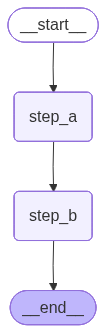

In [85]:
crash_builder = StateGraph(CrashState)
crash_builder.add_node("step_a", step_a)
crash_builder.add_node("step_b", step_b)

crash_builder.add_edge(START, "step_a")
crash_builder.add_edge("step_a", "step_b")
crash_builder.add_edge("step_b", END)

crash_graph = crash_builder.compile(checkpointer=InMemorySaver())
crash_config = {"configurable": {"thread_id": "fault-tolerance-demo"}}
crash_graph

## 6. 第一次执行：step_b 崩溃

注意观察：

- `step_a` 已经执行
- `step_b` 抛异常
- graph 可以通过 checkpoint 查看当前停在哪里

In [86]:
try:
    crash_graph.invoke(
        {
            "stage": "start",
            "value": "",
        },
        crash_config,
    )
except RuntimeError as exc:
    print("caught:", exc)

failed_snapshot = crash_graph.get_state(crash_config)

print("values after crash:", failed_snapshot.values)
print("next after crash:", failed_snapshot.next)
print("step after crash:", failed_snapshot.metadata.get("step"))

step_a executed
step_b executed, fail = True
caught: simulated crash in step_b
values after crash: {'stage': 'after_step_a', 'value': 'a_done'}
next after crash: ('step_b',)
step after crash: 1


## 7. 恢复执行

现在把故障开关关掉。

然后执行：

```python
graph.invoke(None, config)
```

这表示从 checkpoint 里记录的 `next` 节点继续。

In [87]:
crash_flag["fail"] = False

resumed_result = crash_graph.invoke(None, crash_config)

print(resumed_result)

step_b executed, fail = False
{'stage': 'after_step_b', 'value': 'a_done|b_done'}


## 8. 为什么这很重要

如果没有 checkpoint，失败后你只能重新跑整个任务。

如果前面节点有副作用，重新跑会有风险。

例如：

```text
step_a 已经创建了工单
step_b 发送通知时失败
如果重跑全部流程，step_a 可能重复创建工单
```

所以长运行 agent 需要：

- checkpoint
- retry policy
- 幂等设计
- 可观察的 state history

## 9. 副作用风险演示

下面这个节点是不安全的：

```text
先产生外部副作用，再抛异常。
```

如果它被 retry，副作用会重复发生。

In [ ]:
class SideEffectState(TypedDict):
    status: str


external_events: list[str] = []
side_effect_attempts = {"count": 0}


def unsafe_side_effect(state: SideEffectState) -> dict:
    side_effect_attempts["count"] += 1
    external_events.append("send_email")

    if side_effect_attempts["count"] < 2:
        raise ConnectionError("failure after side effect")

    return {"status": "done"}


side_effect_builder = StateGraph(SideEffectState)
side_effect_builder.add_node(
    "unsafe_side_effect",
    unsafe_side_effect,
    retry_policy=RetryPolicy(
        max_attempts=2,
        retry_on=ConnectionError,
        initial_interval=0.0,
    ),
)
side_effect_builder.add_edge(START, "unsafe_side_effect")
side_effect_builder.add_edge("unsafe_side_effect", END)

side_effect_graph = side_effect_builder.compile()
side_effect_graph.invoke({"status": ""})

print("external_events:", external_events)


## 10. 和 Harness 的关系

本仓库 Harness approval 恢复流程和这里很像。

对应关系：

| LangGraph fault tolerance | Harness |
| --- | --- |
| checkpoint | `ExecutionRun` 状态 |
| `thread_id` | `run_id` / session id |
| `next` | 当前等待恢复的步骤 |
| `invoke(None, config)` | `stream_resume_approval(...)` |
| retry policy | 工具失败后的受控重试策略 |

差异是：

```text
LangGraph 提供标准 checkpoint 机制。
Harness 当前是应用层内存实现。
```

## 11. 本讲练习

请判断下面情况适合 retry、checkpoint resume，还是人工处理：

1. HTTP 503，重试一次后可能恢复。
2. 用户没有权限访问订单。
3. 邮件已经发送成功，但后续节点失败。
4. 审批通过后继续执行原任务。

参考答案：

1. retry
2. 人工处理或直接失败，不应盲目 retry
3. checkpoint resume，并避免重复发送邮件
4. checkpoint resume

## 12. 本讲小结

这一讲的核心：

```text
Fault tolerance = retry + checkpoint + resume + idempotency。
```

你现在应该能看懂：

- `RetryPolicy`
- `retry_on`
- `max_attempts`
- checkpoint 失败后如何保存 `next`
- `graph.invoke(None, config)` 如何从失败节点继续
- 为什么外部副作用必须考虑幂等性

下一讲可以继续学习 Memory。